# Data Visualization

**Executive Summary:** Data visualization is the practice of conveying data insights through graphical representations. A good visualization reveals patterns, trends, and outliers, and tells a compelling data-driven story to its audience. Effective visualization follows a clear process: start by formulating questions and understanding your audience, then explore and clean the data, select appropriate chart types, customize the design (colors, labels, annotations) for clarity and accessibility, and finally deploy the results as static figures or interactive dashboards. Throughout, adhere to best practices (e.g. simplicity, consistent scales, accessible color palettes) and avoid common pitfalls like chartjunk or misleading encodings. This report reviews end-to-end workflows, contrasts exploratory vs. explanatory and static vs. interactive visualizations, and provides detailed guidance on using Matplotlib and Seaborn in Python. We catalog chart types (bar, line, scatter, etc.) with their uses, data requirements, code examples, and sample outputs, and offer decision matrices for chart selection. We also cover accessibility (color choice, perceptual design), reproducibility (notebooks, CI tests, web embedding), performance for large data, and present three illustrative examples (EDA, publication-quality figure, interactive dashboard) with code and commentary.  

## 1. Visualization Process and Best Practices

- **Define Question and Audience:** Before plotting anything, ask *“What story do I need to tell?”* and *“Who is my audience?”*. Understand the audience’s needs, context, and technical literacy. Formulate specific questions and identify the key message or insight you want to communicate. For example: “How have sales changed over time?” or “Which categories differ most?”.  
- **Data Collection and Preparation:** Gather and clean the data. Ensure it’s in a useful format (e.g. tidy tables with columns for variables). Check for missing or outlier values. In Python, common tools include pandas and NumPy.  

- **Exploratory Data Analysis (EDA):** Use *quick, iterative* plots to explore the data without worrying about polish. Create simple charts (scatterplots, histograms, box plots, etc.) to look for patterns, relationships, and anomalies. Label raw charts minimally to avoid distraction. This “turn over rocks” phase can reveal hypotheses (correlations, clusters, trends). Don’t skimp on EDA – many insights and potential issues (e.g. data quality, necessary transformations) are discovered here.
- **Chart Selection:** Based on what you want to show (comparison, distribution, correlation, composition, trend, etc.), choose appropriate chart types. For example, use bar charts for categorical comparisons, line charts for trends over time, scatterplots for relationships between two variables, histograms or box plots for distributions, and maps for geospatial data. A quick rule from Tableau: *“One size does not fit all”* – pick the chart that best highlights the relevant pattern. (See the **Chart Selection Guidance** section below for detailed guidelines.)
- **Design and Customize:** Refine the chart with clear labels, legends, and annotations. Use color and shape wisely: limit the palette to a few colors, highlight key data points, and use color schemes appropriate for the data (e.g. sequential palettes for ordered values, categorical palettes for distinct groups). Ensure fonts and line widths are legible, and add context (titles, axis labels, units) so the chart can stand alone. Avoid clutter (excess gridlines, 3D effects, decorative elements) that distract from the data.
- **Accessibility and Perception:** Follow perceptual best practices. For example, avoid misleading scales (start axes at zero when comparing magnitudes), use area and color judiciously (human perception of area and color brightness is non-linear), and ensure colorblind-friendly palettes (avoid using red/green together, use tools like ColorBrewer). Add alt-text or captions if publishing for web accessibility.
- **Iterate and Test:** Evaluate the chart critically. Does it answer the question? Can a non-technical colleague understand it? Get feedback and refine. Include clear takeaways in captions or labels. If deploying in an automated pipeline, use reproducible code (see below) and tests (for example, compare summary statistics or visual regression tests of key figures).
- **Deployment:** Publish the final chart(s) as static images (PNG/SVG), embed in reports or web pages, or deploy as interactive dashboards. For static reports, ensure high-resolution exports (300dpi for print). For interactive applications, consider tools like Plotly, Bokeh, or Dash to let users filter or zoom. Ensure reproducibility by version-controlling both data and code.
- **Pitfalls to Avoid:** Common mistakes include choosing an inappropriate chart type, using misleading scales, overloading the chart with data, and ignoring the story context. Always double-check that the visualization aligns with the message and does not confuse the viewer.  

## 2. Implementation Methods and Workflows

- **Exploratory vs. Explanatory:** Exploratory visualizations are for *analysis*: they help the analyst find patterns in the data, so they tend to be more complex and include more variables (tooltips, interactive filters). Explanatory visualizations are for *communication*: they present a specific finding clearly to an audience. As Cole Nussbaumer Knaflic notes, exploratory charts are like “turning over 100 rocks to find gemstones,” whereas explanatory charts highlight those gemstones to tell a story. In practice, one often starts with rich exploratory plots and then simplifies or annotates them for the final explanatory figure.

- **Static vs. Interactive:** Static charts (PNG, PDF, etc.) are fixed images. They excel at delivering a clear message quickly. Interactive visualizations (web dashboards, Jupyter widgets) let users drill down and explore the data themselves. Use static graphics when you have a specific message or need for print-quality figures (papers, reports), and use interactive tools (Plotly/Dash, Bokeh, Shiny, etc.) when users must investigate the data (e.g. dashboards for analysts).

- **Reproducible Pipelines:** Use version-controlled code and notebooks (Git, Docker/Conda environments) so others can regenerate the plots. Write scripts or notebooks that load raw data, preprocess, and produce charts. Parameterize scripts to accept different data inputs. Use continuous integration to run tests on figures (for example, checking key statistics or using image diff tools). For sharing: notebooks (Jupyter, Colab) and `nbconvert` for static reports, or libraries like `panel` or `voila` to deploy interactive dashboards. Document dependencies and random seeds for reproducibility.

## 3. Matplotlib (Python)

**Installation:** Matplotlib can be installed via `pip` or `conda`. For example:  
```bash
pip install matplotlib
# or for conda users:
conda install -c conda-forge matplotlib
```  
This pulls in required dependencies (numpy, etc.). It’s included in Anaconda distributions as well. Matplotlib supports Python 3.8+ (as of v3.11).

**Core API:** Matplotlib has two main interfaces: the *pyplot* (stateful) interface and the *object-oriented* (OO) interface. The `pyplot` interface (`import matplotlib.pyplot as plt`) provides MATLAB-like functions that act on the current figure and axes. Each `plt` command (e.g. `plt.plot()`, `plt.bar()`, `plt.scatter()`) adds to the current axes. For example: 

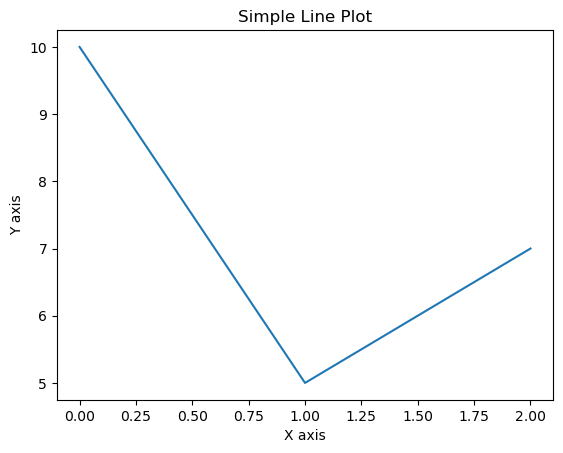

In [1]:
import matplotlib.pyplot as plt
plt.plot([0, 1, 2], [10, 5, 7])
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.title("Simple Line Plot")
plt.show()

This creates a line chart from the Y-values `[10,5,7]` against their index (0,1,2). The OO interface uses `Figure` and `Axes` objects explicitly. For example:

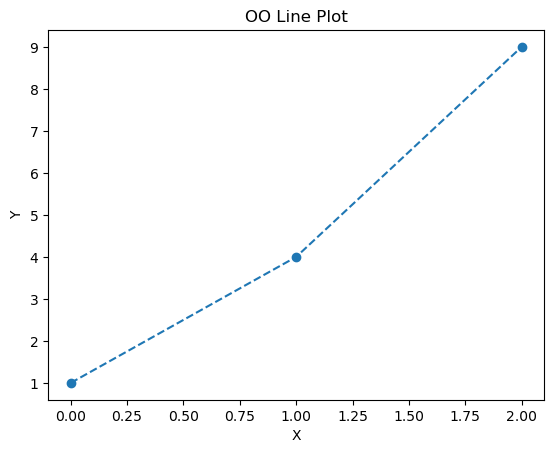

In [2]:
fig, ax = plt.subplots()
ax.plot([0,1,2], [1,4,9], marker='o', linestyle='--')
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("OO Line Plot")
plt.show()

Both produce a line chart. The OO style is more flexible (better control over subplots), while `pyplot` is quick for simple plots.

**Customization:** Matplotlib is highly customizable. You can change colors, markers, line styles, fonts, etc. for example: `plt.plot(x, y, 'ro--', label='Data')` plots red circles with dashed lines. You can set axis limits (`plt.xlim()`), aspect ratio, annotate (`plt.annotate()`), and use `plt.style.use('ggplot')` or other built-in styles. Global defaults can be set with `matplotlib.rcParams` or a style sheet. For example, to use a white background and serif fonts:

In [3]:
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['font.family'] = 'serif'

**Performance Tips:** For large datasets, Matplotlib can be slow. A few optimizations:  

- **Path simplification:** By default, Matplotlib *simplifies* dense line plots by merging close points. You can adjust `mpl.rcParams['path.simplify_threshold']` to control when to simplify. Larger thresholds speed up rendering.  
- **Marker subsampling:** For scatter/line plots with many markers, use `markevery` to plot only every Nth point (e.g., `plt.plot(x, y, markevery=10)`).  
- **Chunking (Agg backend):** Set `mpl.rcParams['agg.path.chunksize'] = N` (e.g. 10000) to split very long lines into segments, which can reduce memory usage.  
- **Fast style:** Using `plt.style.use('fast')` automatically sets simplification and chunking for large data.  

**Common Patterns:** Matplotlib works well for static, publication-quality figures. Typical workflows: (1) Import data into numpy/pandas, (2) Create a `Figure` and one or more `Axes` (`fig, ax = plt.subplots()`), (3) Call plotting methods (`ax.plot()`, `ax.bar()`, etc.), (4) Label and style, (5) Save with `plt.savefig("fig.png", dpi=300)`.  

**Examples:** Below are code examples illustrating Matplotlib:

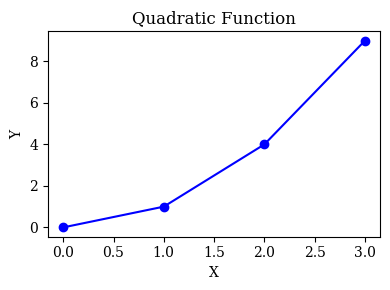

In [4]:
import matplotlib.pyplot as plt

# Example 1: Line plot
x = [0, 1, 2, 3]
y = [0, 1, 4, 9]
plt.figure(figsize=(4,3))
plt.plot(x, y, 'b-o')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Quadratic Function")
plt.tight_layout()
plt.show()

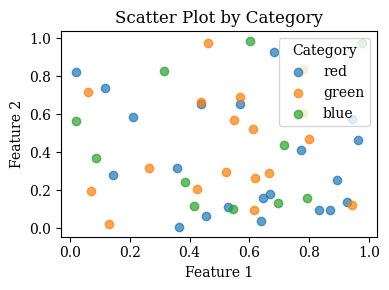

In [5]:
# Example 2: Scatter plot with legend
import numpy as np
np.random.seed(0)
x = np.random.rand(50)
y = np.random.rand(50)
colors = np.random.choice(['red','green','blue'], size=50)
plt.figure(figsize=(4,3))
for c in ['red','green','blue']:
    mask = (colors==c)
    plt.scatter(x[mask], y[mask], label=c, alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Category")
plt.title("Scatter Plot by Category")
plt.tight_layout()
plt.show()

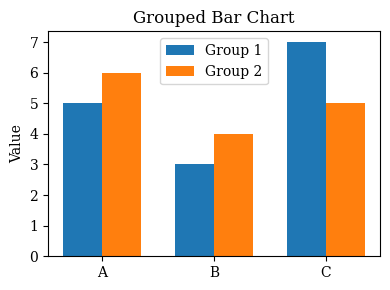

In [6]:
# Example 3: Grouped bar chart
categories = ['A','B','C']
values1 = [5, 3, 7]
values2 = [6, 4, 5]
import numpy as np
ind = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(4,3))
ax.bar(ind, values1, width, label='Group 1')
ax.bar(ind+width, values2, width, label='Group 2')
ax.set_xticks(ind+width/2)
ax.set_xticklabels(categories)
ax.set_ylabel("Value")
ax.set_title("Grouped Bar Chart")
ax.legend()
plt.tight_layout()
plt.show()

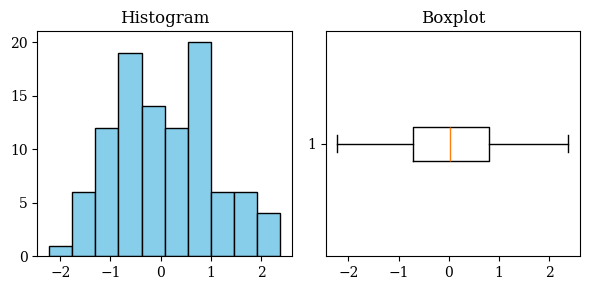

In [7]:
# Example 4: Histogram and Boxplot
data = np.random.randn(100)
fig, axs = plt.subplots(1,2, figsize=(6,3))
axs[0].hist(data, bins=10, color='skyblue', edgecolor='black')
axs[0].set_title("Histogram")
axs[1].boxplot(data, vert=False)
axs[1].set_title("Boxplot")
plt.tight_layout()
plt.show()

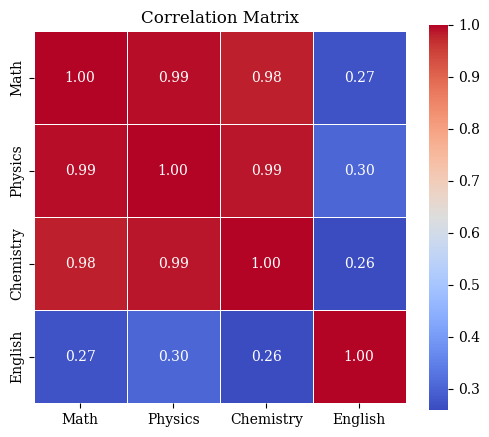

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    "Math": [85, 90, 78, 92, 88, 76, 95, 89],
    "Physics": [80, 88, 75, 90, 85, 70, 93, 87],
    "Chemistry": [82, 91, 77, 89, 86, 74, 94, 88],
    "English": [70, 75, 80, 85, 78, 82, 88, 81]
}
df = pd.DataFrame(data)
corr = df.corr()
plt.figure(figsize=(6,5))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix")
plt.show()

## 4. Seaborn (Python)

**Installation:** Seaborn is built on top of Matplotlib and is installed similarly. For example:  
```bash
pip install seaborn
# or conda install -c conda-forge seaborn
```  
This installs Seaborn and its dependencies (numpy, pandas, matplotlib). Official docs recommend also installing optional dependencies (`seaborn[stats]`) for advanced plots, and using `seaborn.objects` for experimental interface.  

**Core API:** Seaborn provides high-level plotting functions that work well with pandas DataFrames. There are two types of functions: *axes-level* and *figure-level*. Axes-level functions (e.g. `sns.scatterplot`, `sns.boxplot`, `sns.histplot`) plot onto a single Matplotlib `Axes` object, and return that Axes. Figure-level functions (e.g. `sns.relplot`, `sns.catplot`, `sns.displot`, `sns.pairplot`) create a `FacetGrid` or `PairGrid` and can automatically create multiple subplots/facets.  

For example, an axes-level barplot:

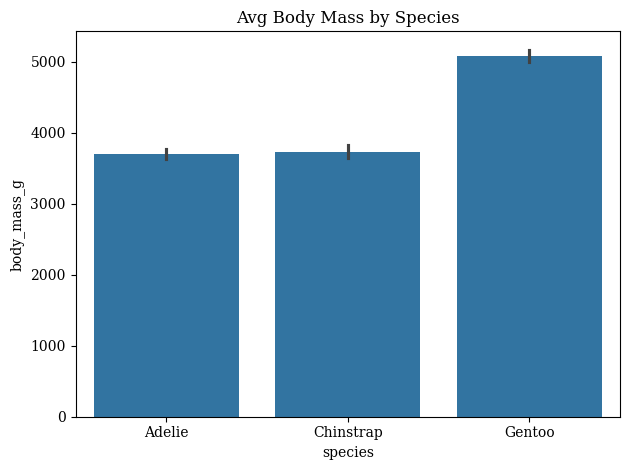

In [13]:
import seaborn as sns
penguins = sns.load_dataset("penguins")
sns.barplot(data=penguins, x="species", y="body_mass_g")
plt.title("Avg Body Mass by Species")
plt.tight_layout()
plt.show()

**Customization:** Seaborn themes make styling easy. For example:
```python
sns.set_theme(style="whitegrid", palette="deep")
```
sets a white grid background and a default color palette. Other context settings (`sns.set_context`) adjust font sizes for notebooks vs slides. The `palette` argument in plotting functions chooses a color scheme (e.g. `palette="bright"` or `palette="colorblind"`). Unlike raw Matplotlib, Seaborn automatically adds informative axis labels and legends for DataFrame columns, but you can still customize with Matplotlib commands (e.g. `plt.xlabel`, `plt.savefig`).

**Examples:** Seaborn excels at statistical and multi-plot charts. Here are some illustrative examples:

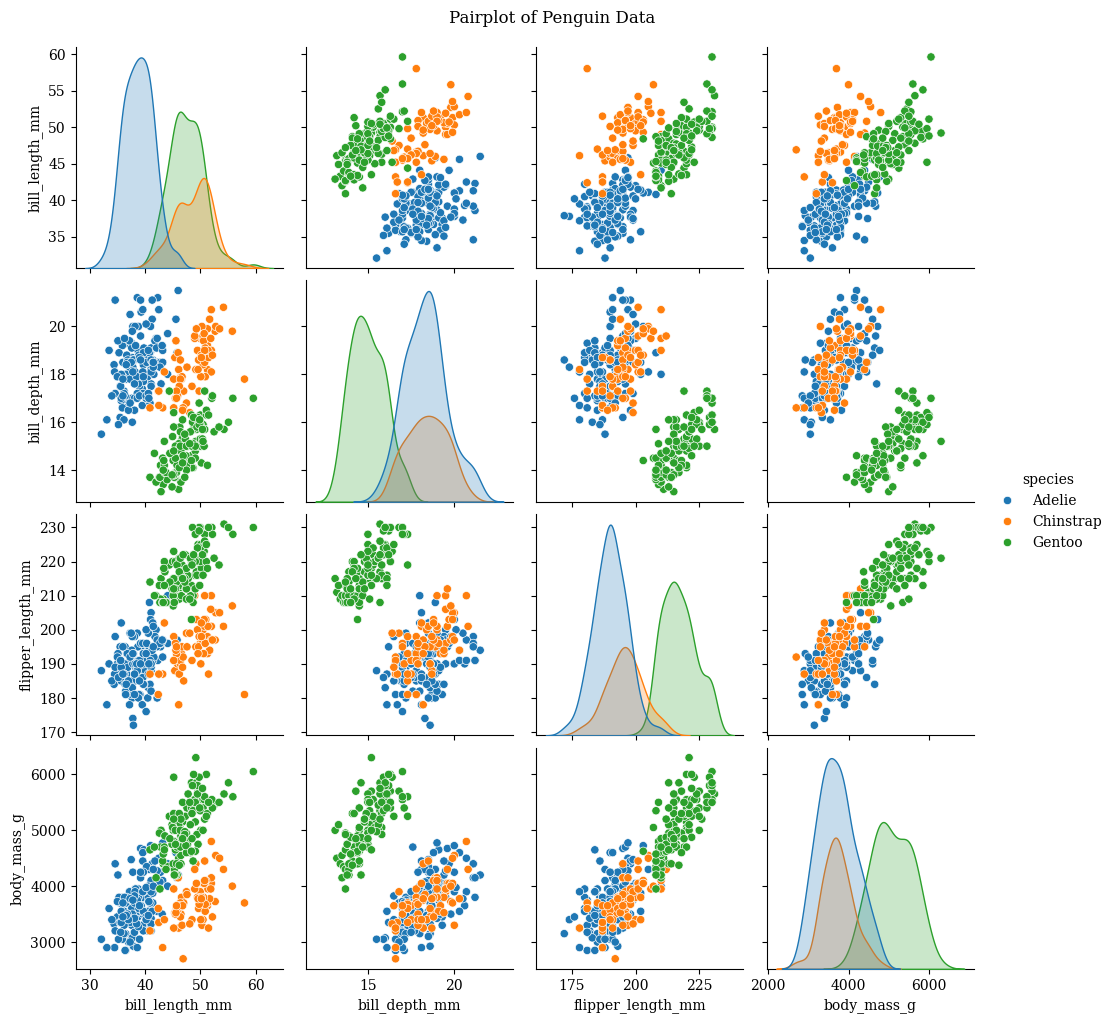

In [12]:
import seaborn as sns

# Example 1: Pairplot (matrix of scatterplots + histograms)
df = sns.load_dataset("penguins").dropna()
sns.pairplot(df, hue="species")
plt.suptitle("Pairplot of Penguin Data", y=1.02)
plt.show()

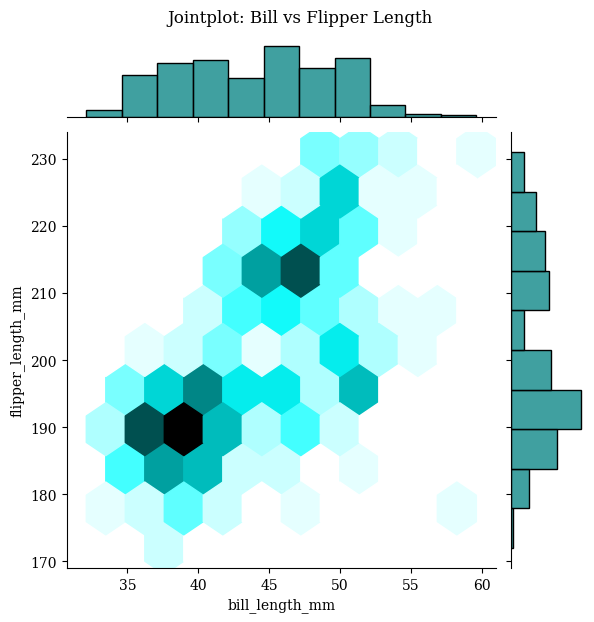

In [14]:
# Example 2: Jointplot (bivariate plot with marginals)
sns.jointplot(data=df, x="bill_length_mm", y="flipper_length_mm", kind="hex", color="teal")
plt.suptitle("Jointplot: Bill vs Flipper Length", y=1.03)
plt.show()

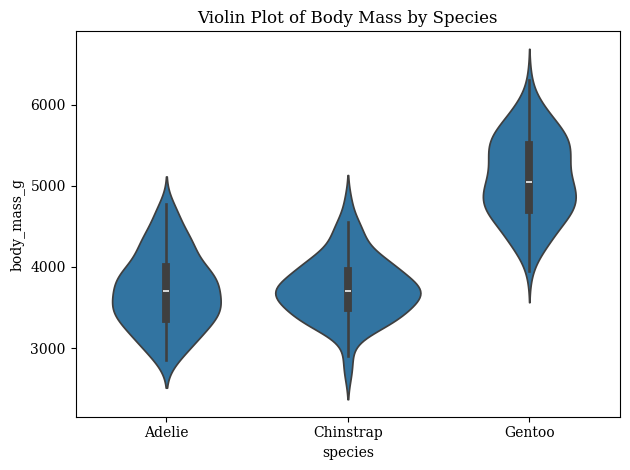

In [15]:
# Example 3: Violin plot (distribution by category)
sns.violinplot(data=df, x="species", y="body_mass_g")
plt.title("Violin Plot of Body Mass by Species")
plt.tight_layout()
plt.show()

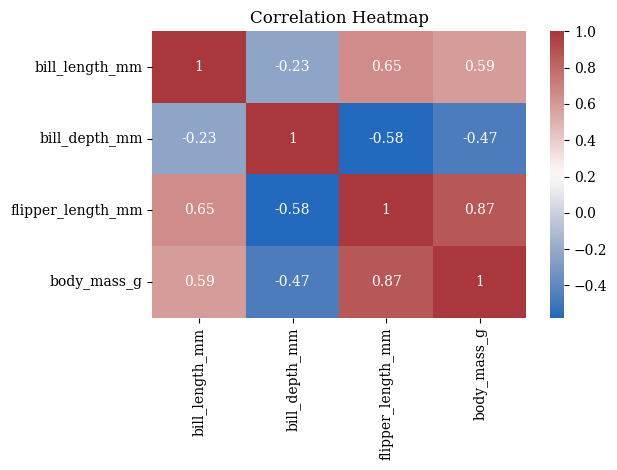

In [17]:
# Example 4: Heatmap using seaborn (stronger API)
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='vlag')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

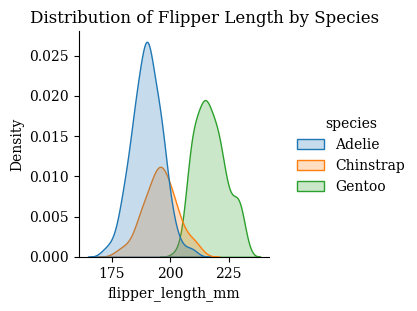

In [18]:
# Example 5: Displot (figure-level histogram faceted by species)
sns.displot(df, x="flipper_length_mm", hue="species", kind="kde", fill=True, height=3)
plt.suptitle("Distribution of Flipper Length by Species", y=1.02)
plt.show()

## 5. Chart Types Taxonomy

Below is a catalog of common chart types, their purposes, data requirements, and code snippets. For each, we show *when to use* and *when to avoid*.

- **Bar Chart:**  
  *Purpose:* Compare categories (discrete groups) on a single measure.  
  *Data:* Categorical `x`, numeric `y` (one bar per category).  
  *Use when:* Showing totals or means by category. *Avoid when:* There are too many categories (use small-multiples or alternative encodings then).  
  *Example (Matplotlib):* 

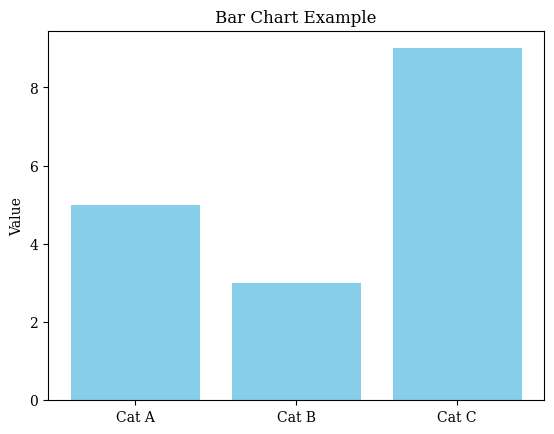

In [19]:
cats = ['Cat A','Cat B','Cat C']
values = [5, 3, 9]
plt.bar(cats, values, color='skyblue')
plt.ylabel("Value")
plt.title("Bar Chart Example")
plt.show()

- **Grouped / Stacked Bar:**  
  *Purpose:* Compare categories across sub-groups.  
  *Data:* 2 categorical variables and one numeric (e.g. category and subgroup).  
  *Use when:* You want to compare categories *and* breakdown by a second variable. Stacked bars emphasize composition; grouped bars emphasize each subgroup’s value.  
  *Example (Matplotlib grouped bar):* see the *Grouped Bar Chart* in Matplotlib examples.  
  *Example (Matplotlib stacked bar):* 

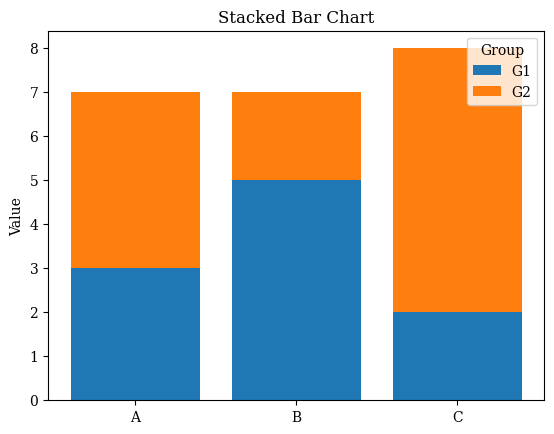

In [20]:
  labels = ['A','B','C']
  v1 = [3, 5, 2]
  v2 = [4, 2, 6]
  plt.bar(labels, v1, label='G1')
  plt.bar(labels, v2, bottom=v1, label='G2')
  plt.ylabel("Value")
  plt.legend(title="Group")
  plt.title("Stacked Bar Chart")
  plt.show()

- **Line Chart:**  
  *Purpose:* Show trends over an ordered variable (usually time).  
  *Data:* Numeric or ordinal `x`, numeric `y`. Points are connected.  
  *Use when:* Displaying how a value changes over time or another sequential axis. *Avoid when:* The `x` variable has no meaningful order or is categorical. Also, avoid line charts for categories.  
  *Example (Matplotlib):* 

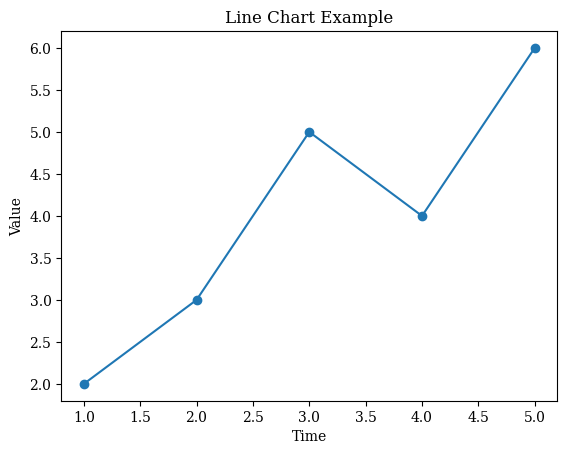

In [21]:
  time = [1,2,3,4,5]
  val = [2, 3, 5, 4, 6]
  plt.plot(time, val, marker='o', linestyle='-')
  plt.xlabel("Time")
  plt.ylabel("Value")
  plt.title("Line Chart Example")
  plt.show()

- **Scatter Plot:**  
  *Purpose:* Show relationship/correlation between two variables.  
  *Data:* Two numeric variables (`x`, `y`); optionally a categorical variable for color or marker.  
  *Use when:* Exploring or showing relationships or clusters in data. *Avoid when:* `x` and `y` are not related, or there’s a strong ordering (use line chart for trend).  
  *Example (Matplotlib):*

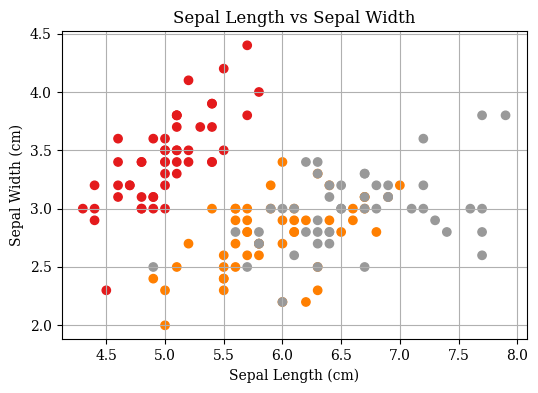

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
iris = sns.load_dataset("iris")

# Scatter plot
plt.figure(figsize=(6, 4))
plt.scatter(
    iris["sepal_length"],
    iris["sepal_width"],
    c=iris["species"].astype("category").cat.codes,
    cmap="Set1"
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.grid(True)
plt.show()

- **Histogram:**  
  *Purpose:* Show the distribution (frequency) of a single numeric variable.  
  *Data:* One numeric variable (vector of values).  
  *Use when:* You need to see data distribution shape, spread, skewness, or to compare distributions with multiple histograms. *Avoid when:* Data is categorical (use bar chart instead) or if binning would hide the pattern.  
  *Example (Matplotlib):*

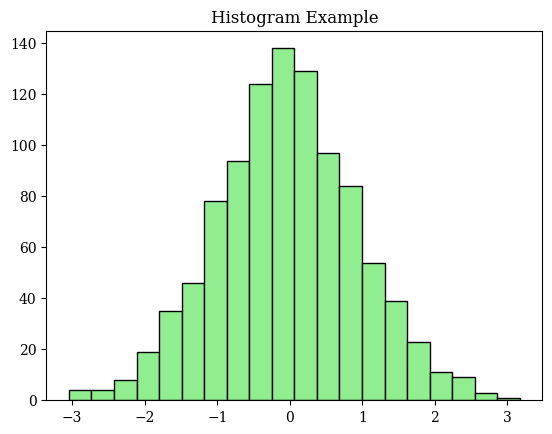

In [23]:
  data = np.random.randn(1000)
  plt.hist(data, bins=20, color='lightgreen', edgecolor='black')
  plt.title("Histogram Example")
  plt.show()

- **Box Plot:**  
  *Purpose:* Summarize distribution (median, quartiles, outliers) of a numeric variable by category.  
  *Data:* Categorical `x`, numeric `y`.  
  *Use when:* You want to compare distributions across groups, highlighting medians and spread. *Avoid when:* Data has few points (box plot may be misleading), or if exact values are needed.  

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23936\2229138655.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data1, data2], labels=['Group1','Group2'])


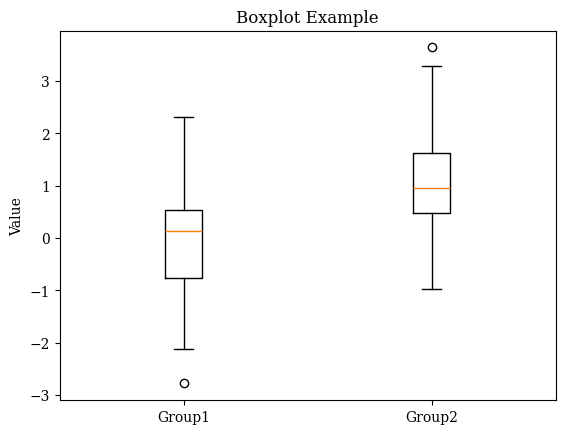

In [24]:
  data1 = np.random.randn(100)
  data2 = np.random.randn(100) + 1
  plt.boxplot([data1, data2], labels=['Group1','Group2'])
  plt.ylabel("Value")
  plt.title("Boxplot Example")
  plt.show()

- **Violin Plot:**  
  *Purpose:* Show distribution shape (density) for numeric data by category, similar to boxplots but revealing multimodality.  
  *Data:* Categorical `x`, numeric `y`.  
  *Use when:* You want to see a smooth estimate of distribution, including multiple peaks. *Avoid when:* Sample sizes are small (density estimate is noisy) or a simpler boxplot suffices.  
  *Example (Seaborn):*  

<Axes: xlabel='species', ylabel='body_mass_g'>

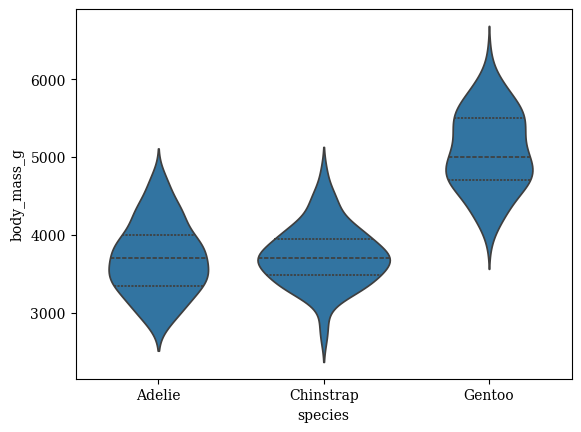

In [25]:
  sns.violinplot(x="species", y="body_mass_g", data=penguins, inner="quartile")

- **Heatmap:**  
  *Purpose:* Visualize matrix or 2D data (e.g. correlation matrix or spatial grid).  
  *Data:* 2D array (matrix) of numeric values, or DataFrame of numerical fields.  
  *Use when:* You have matrix data (e.g. correlations, table of counts), or you need a grid colored by value. *Avoid when:* Data is not inherently grid-like, or when other plots convey it better.  
  *Example (Matplotlib with imshow):*  

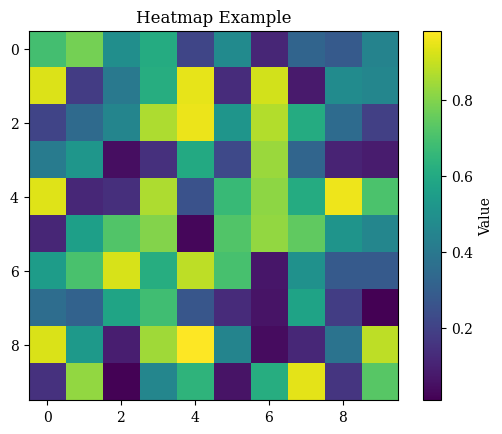

In [26]:
  matrix = np.random.rand(10,10)
  plt.imshow(matrix, cmap='viridis', interpolation='nearest')
  plt.colorbar(label="Value")
  plt.title("Heatmap Example")
  plt.show()

- **Pairplot / Scatterplot Matrix:**  
  *Purpose:* Explore pairwise relationships and distributions across multiple variables.  
  *Data:* N numeric variables (usually from a DataFrame).  
  *Use when:* Doing EDA to quickly spot correlations and distributions for all variable pairs. *Avoid when:* More than ~6 variables (plot becomes too crowded).  
  *Example (Seaborn):*  

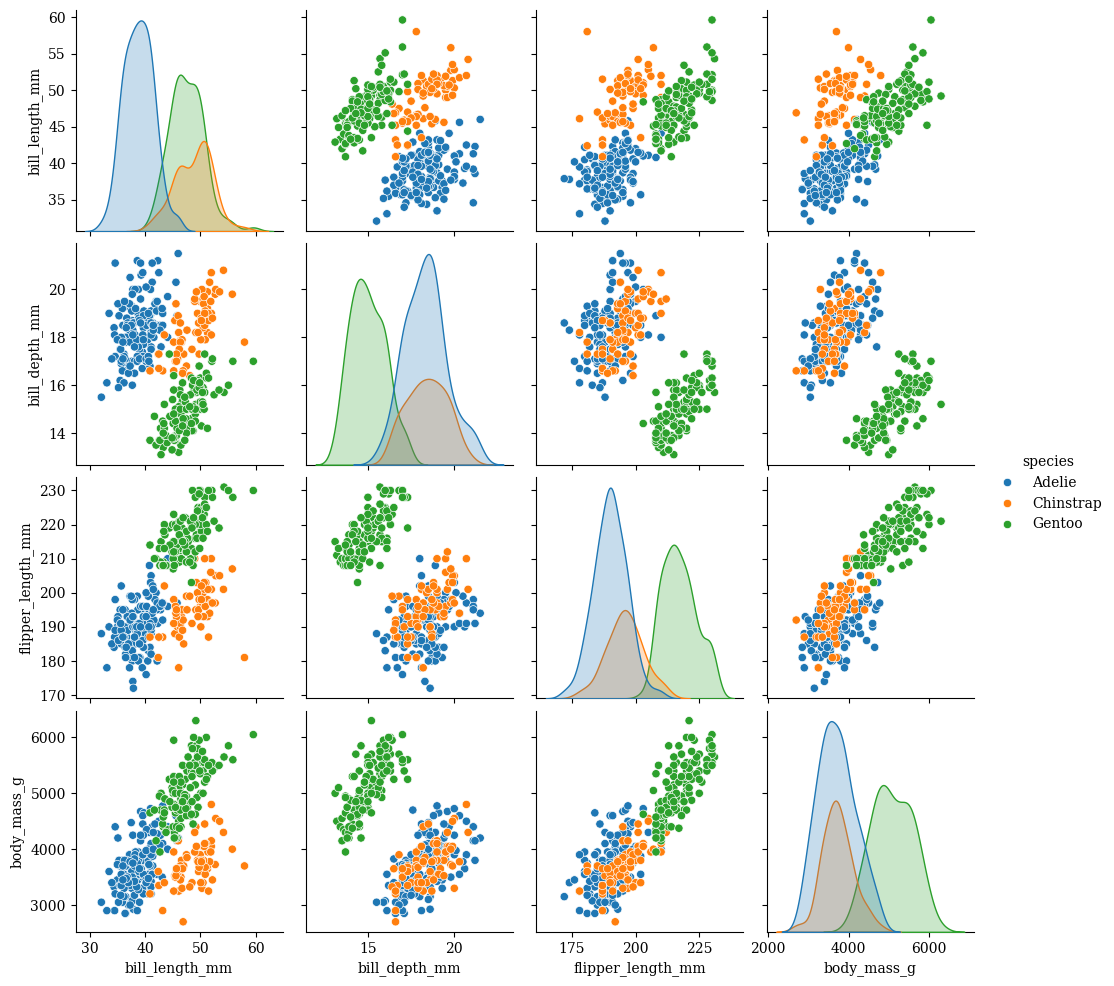

In [28]:
sns.pairplot(df, hue="species")
plt.show()

- **Jointplot:**  
  *Purpose:* Show bivariate distribution of two variables plus their univariate distributions.  
  *Data:* Two numeric variables.  
  *Use when:* Focusing on the relationship between a specific pair of variables along with marginals. *Avoid when:* You need to show more than two variables at once.  

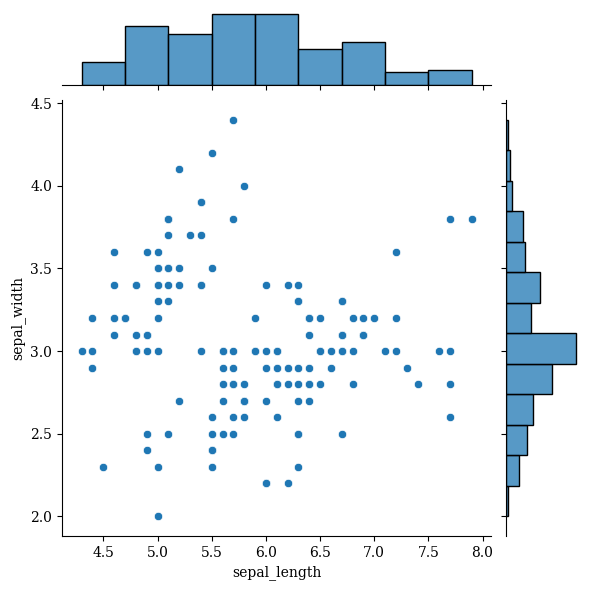

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load sample dataset
df = sns.load_dataset("iris")

# Jointplot
sns.jointplot(
    data=df,
    x="sepal_length",
    y="sepal_width"
)

plt.show()

- **Area (Stackplot):**  
  *Purpose:* Like a stacked line chart, emphasizes cumulative totals over time.  
  *Data:* One numeric `x`, multiple numeric `y_i` series that stack vertically.  
  *Use when:* You want to show how several quantities contribute to a total over time. *Avoid when:* The individual trends matter more than the total, as stacking obscures individual variation.  
  *Example (Matplotlib):* The stackplot example below shows population over time for three regions.  
  *Sample Output:* 

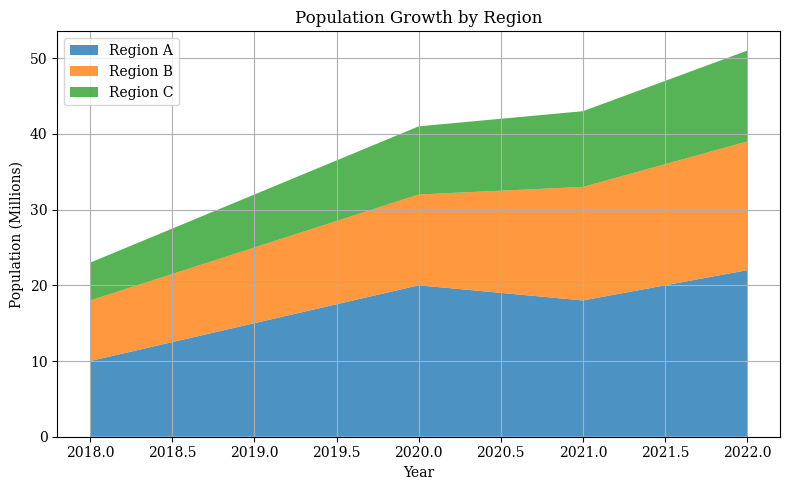

In [30]:
import matplotlib.pyplot as plt

# X-axis (Time)
years = [2018, 2019, 2020, 2021, 2022]

# Three data series
region_a = [10, 15, 20, 18, 22]
region_b = [8, 10, 12, 15, 17]
region_c = [5, 7, 9, 10, 12]

# Create stackplot
plt.figure(figsize=(8, 5))
plt.stackplot(
    years,
    region_a,
    region_b,
    region_c,
    labels=["Region A", "Region B", "Region C"],
    alpha=0.8
)

# Labels and title
plt.title("Population Growth by Region")
plt.xlabel("Year")
plt.ylabel("Population (Millions)")
plt.legend(loc="upper left")

plt.grid(True)
plt.tight_layout()
plt.show()

- **Pie Chart:**  
  *Purpose:* Show part-to-whole (composition) for categorical data.  
  *Data:* Single categorical variable with values summing to 100%.  
  *Use when:* You want to emphasize one or few parts of a whole, and the number of categories is small (<= 5). *Avoid when:* Many categories (pie becomes cluttered), or when precise comparison is needed (bar charts are better for comparing parts).  
  *Example (Matplotlib):* 

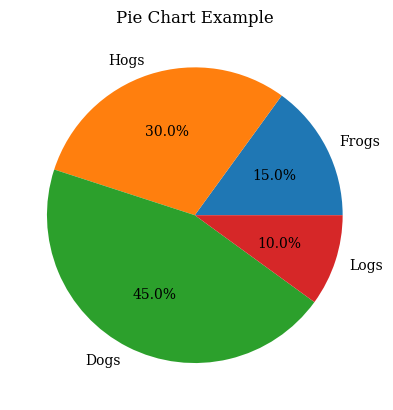

In [31]:
  sizes = [15, 30, 45, 10]
  labels = ['Frogs','Hogs','Dogs','Logs']
  plt.pie(sizes, labels=labels, autopct='%1.1f%%')
  plt.title("Pie Chart Example")
  plt.show()

## 6. Chart Selection Guidance

The table below helps decide which chart fits your data and goal:

| Data & Goal              | Typical Chart Types           | Data Shape                            | Notes                                           |
|--------------------------|-------------------------------|---------------------------------------|-------------------------------------------------|
| **Compare categories**   | Bar chart (grouped/stacked)   | 1 categorical × 1 numeric             | Use grouped bars for subcategories|
| **Show trend over time** | Line chart, Area chart        | 1 time/ordinal × 1+ numeric           | Use multiple lines for multiple series          |
| **Distribution**         | Histogram, Box plot, Violin   | 1 numeric                             | Box/Violin if comparing across groups           |
| **Correlation**          | Scatter plot, Bubble chart    | 2 numeric (optional 3rd for size)     | Can color by a category for groups             |
| **Composition**          | Pie, Stacked bar, Treemap     | 1 categorical × numeric parts         | Pie for simple part-to-whole (few parts) |
| **Geospatial**           | Choropleth map, Cartogram     | Geospatial + numeric                  | Requires mapping coordinates or regions        |
| **Hierarchy**            | Treemap, Sunburst             | Hierarchical categories × size        | Effective for multiple levels                   |
| **Distribution across time or groups** | Box/Violin plot   | 1 categorical × 1 numeric             | Use to compare distributions by group          |

This is a guideline; consider your data dimensionality and what pattern you wish to highlight. As Tableau advises, *“Choose the right charts and graphs for the job”* and use color and composition to draw attention to the message.

## 7. Illustrative Examples

### 7.1 Exploratory Data Analysis (Small Dataset)

**Scenario:** We have a small dataset of penguin measurements (from `seaborn.load_dataset("penguins")`). We want to explore relationships between variables to generate hypotheses.

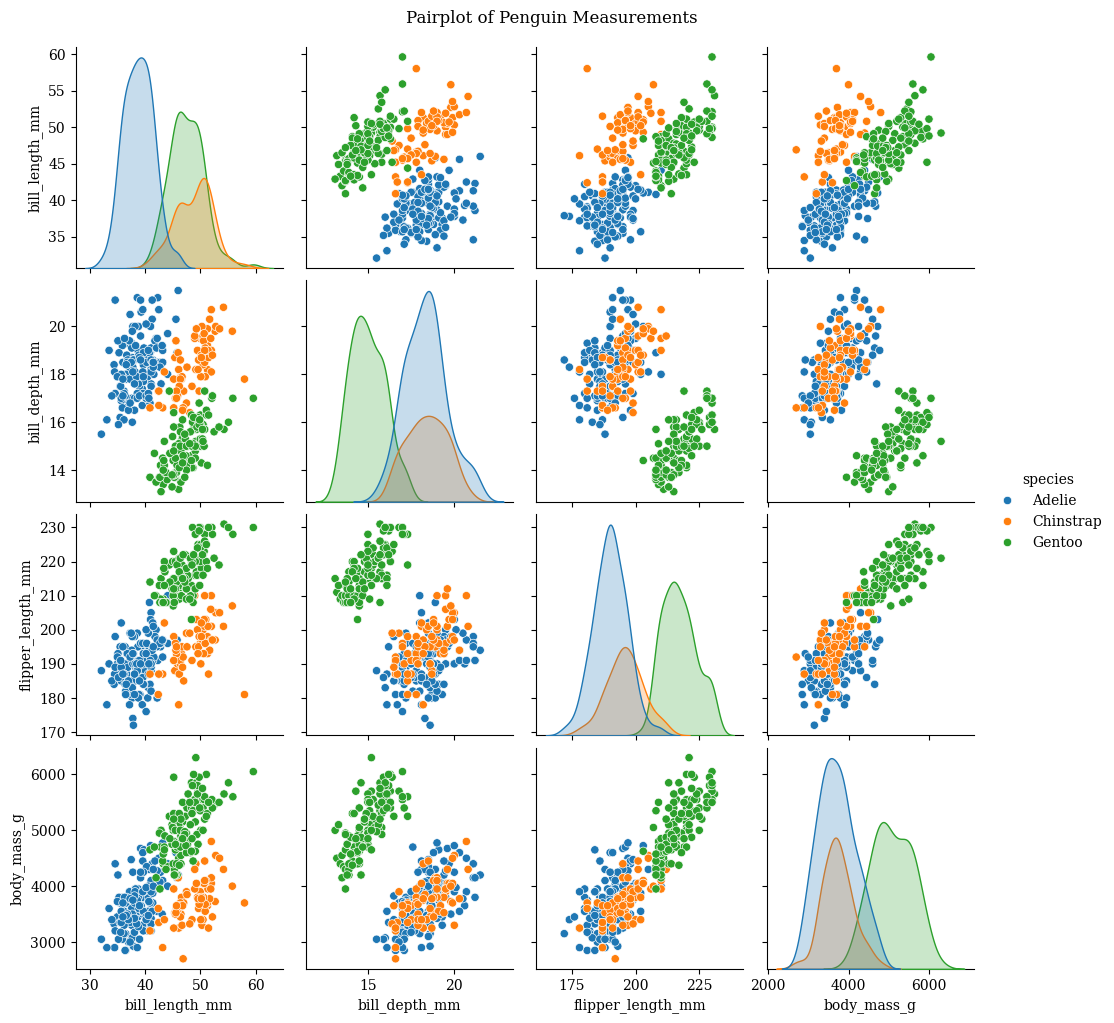

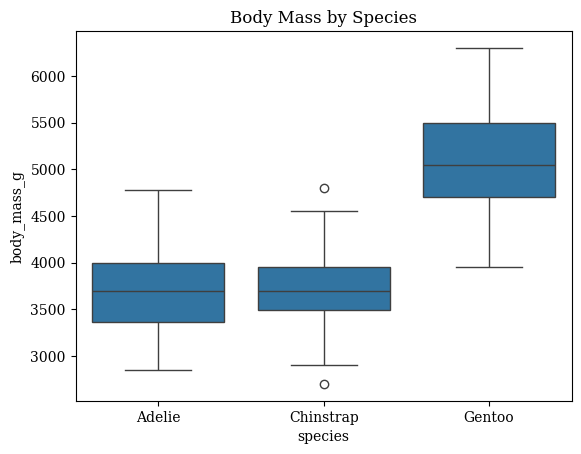

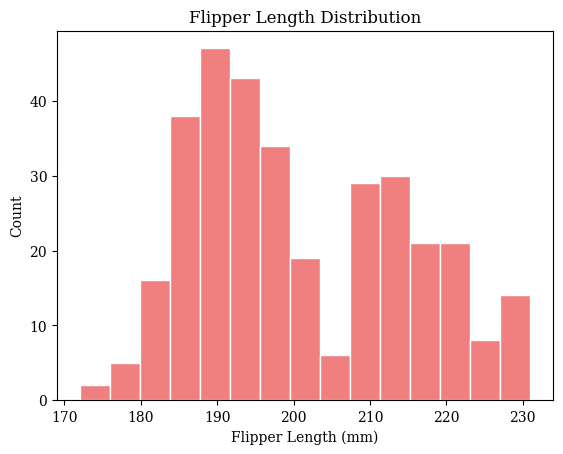

In [34]:
import seaborn as sns
import pandas as pd
df = sns.load_dataset("penguins").dropna()

# Scatterplot matrix (pairplot) to see relationships:
sns.pairplot(df, vars=["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"], hue="species")
plt.suptitle("Pairplot of Penguin Measurements", y=1.02)
plt.show()

# Boxplot: compare body mass by species
sns.boxplot(data=df, x="species", y="body_mass_g")
plt.title("Body Mass by Species")
plt.show()

# Histogram: distribution of flipper lengths
plt.hist(df.flipper_length_mm, bins=15, color='lightcoral', edgecolor='white')
plt.title("Flipper Length Distribution")
plt.xlabel("Flipper Length (mm)")
plt.ylabel("Count")
plt.show()

These plots (not shown) would reveal, for example, that *Species C* has generally larger body mass, and the flipper lengths cluster differently by species. The scatter matrix might show a positive correlation between bill length and body mass. From this exploratory analysis, we might hypothesize that species and bill dimensions are related, guiding a more formal analysis or a targeted visualization.

### 7.2 Publication-Quality Figure

**Scenario:** We want to produce a polished figure for a paper, showing how penguin body mass varies by species and sex.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23936\3947775917.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df, x="species", y="body_mass_g", hue="sex", ci="sd", palette="Set2")


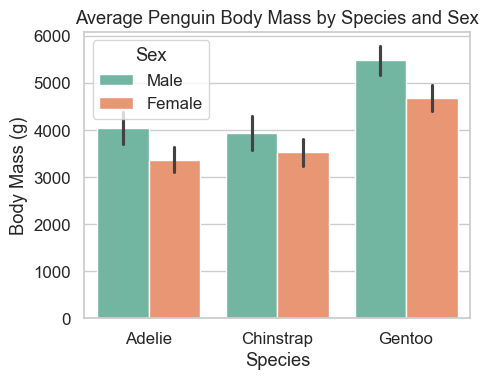

In [35]:
# Publication-quality seaborn catplot
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(5,4))
sns.barplot(data=df, x="species", y="body_mass_g", hue="sex", ci="sd", palette="Set2")
plt.title("Average Penguin Body Mass by Species and Sex")
plt.ylabel("Body Mass (g)")
plt.xlabel("Species")
plt.legend(title="Sex")
plt.tight_layout()
plt.savefig("pub_fig.png", dpi=300)

*Expected result:* A clean grouped bar chart with error bars (standard deviation). Axes are labeled with units, legend is outside or inset, colors are pastel (Set2) for print. The image file `pub_fig.png` would be 300dpi for publication.

### 7.3 Interactive Dashboard

**Scenario:** We build a simple interactive dashboard (e.g. with Plotly Dash or Panel) for real-time data exploration. Here we sketch code (conceptual):

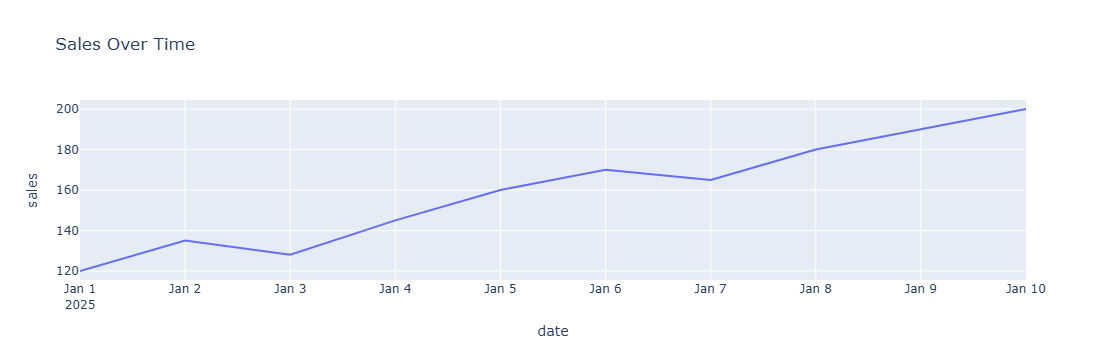

In [37]:
import pandas as pd
import plotly.express as px

# Create sample data
df_live = pd.DataFrame({
    "date": pd.date_range("2025-01-01", periods=10),
    "product": ["Product A"] * 10,
    "sales": [120, 135, 128, 145, 160, 170, 165, 180, 190, 200]
})

# Plot line chart
fig = px.line(
    df_live,
    x="date",
    y="sales",
    title="Sales Over Time"
)

fig.update_layout(hovermode="x unified")

fig.show()

In this interactive figure (which would pop up in a browser), users can hover to see exact values, zoom in/out, and toggle product lines. This allows self-driven exploration of seasonal trends. A full dashboard would include drop-downs or sliders (e.g. select date range or product), tables, etc., but those are beyond this summary.